# Benchmarking `nvjpeg` 📊

# 📈 Data Visualization & Analysis

Now we will plot the collected data to understand the results. We will focus on:
1.  **Rate-Distortion:** How do quality metrics (like VMAF) change with file size?
2.  **Quality vs. File Size:** How does the `-quality` setting impact file size for different subsampling methods?
3.  **Encoding Performance:** Which DCT method is fastest? How does resolution affect encoding time?
4.  **Decoding Performance:** How does resolution affect decoding time?

In [1]:
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/s248508/Pictures/benchmark-result/nvjpeg_results_1280x720.csv")
df.head()

,img_name,subsampling,quality,enc_avg_time_milliseconds,enc_avg_fps,enc_avg_mps,dec_avg_time_milliseconds,dec_avg_fps,dec_avg_mps,compressed_size_bytes,compression_ratio,bpp,psnr,ssim
0,r000da54ft.rgb,444,10,1.07,934.579,861.308411,3.12,320.513,295.384615,49052,56.364674,0.425799,28.8092,0.862350
1,r000da54ft.rgb,444,20,0.96,1041.667,960.000000,3.43,291.545,268.688047,66685,41.460598,0.578863,32.5277,0.928098
2,r000da54ft.rgb,444,30,1.00,1000.000,921.600000,3.36,297.619,274.285714,81967,33.730648,0.711519,34.3729,0.949225
3,r000da54ft.rgb,444,40,0.98,1020.408,940.408163,3.62,276.243,254.585635,95035,29.092440,0.824957,35.6236,0.960452
4,r000da54ft.rgb,444,50,1.00,1000.000,921.600000,3.74,267.380,246.417112,107601,25.694928,0.934036,36.5846,0.967929


## Encoding Parameters vs. quality metrics

In [3]:
plt.style.use('default')

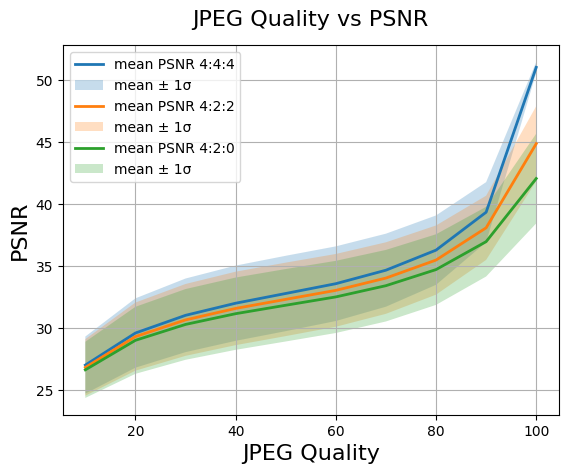

In [4]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs PSNR", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean PSNR 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean PSNR 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean PSNR 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")


ax.legend()
plt.show()

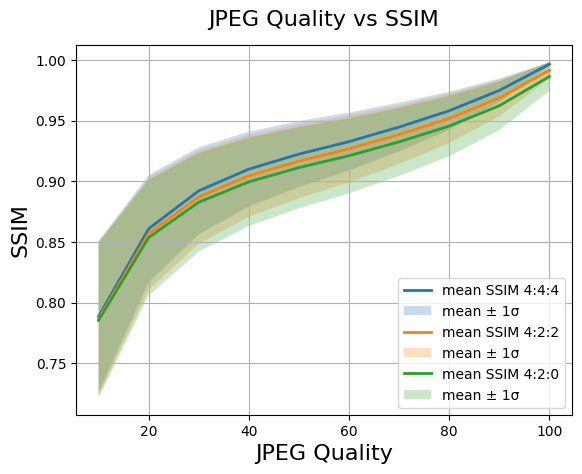

In [5]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs SSIM", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("SSIM", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean SSIM 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean SSIM 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean SSIM 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

## Format vs. File Size


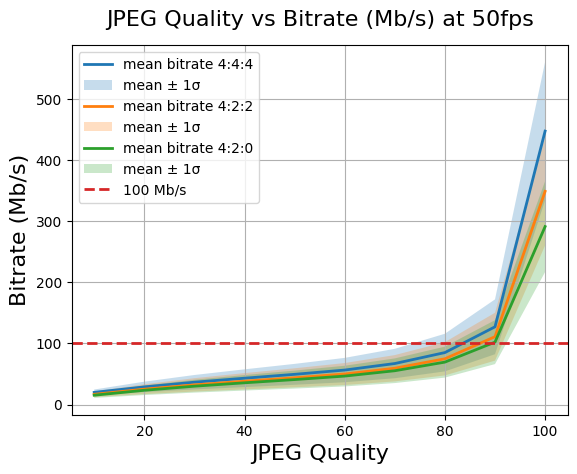

In [6]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_444 = stats_444["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_422 = stats_422["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_420 = stats_420["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Bitrate (Mb/s) at 50fps", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Bitrate (Mb/s)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean bitrate 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean bitrate 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean bitrate 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.axhline(100, color="tab:red",   linestyle="--", linewidth=2, label="100 Mb/s")


ax.legend()
plt.show()

We can observe an explosion in file size from quality 95 onwards, and a sharp increase from quality 90 onwards.

## Encoding Parameters vs. Performance

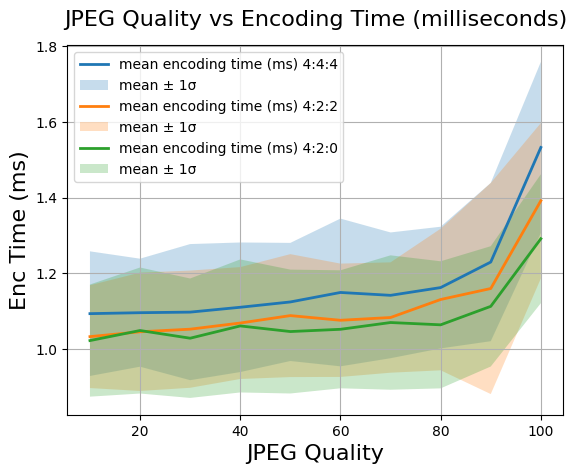

In [7]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean encoding time (ms) 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean encoding time (ms) 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean encoding time (ms) 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

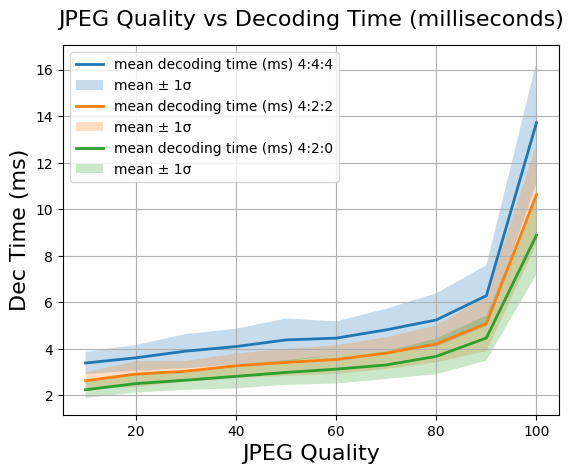

In [8]:
# Aggregate per quality across experiments
stats_444 = (
    df[df["subsampling"] == 444].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_444["quality"].to_numpy()
m_444 = stats_444["mean"].to_numpy()
s_444 = stats_444["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_444 = np.nan_to_num(s_444, nan=0.0)

stats_422 = (
    df[df["subsampling"] == 422].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_422 = stats_422["mean"].to_numpy()
s_422 = stats_422["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_422 = np.nan_to_num(s_422, nan=0.0)

stats_420 = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_420 = stats_420["mean"].to_numpy()
s_420 = stats_420["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_420 = np.nan_to_num(s_420, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_444, label="mean decoding time (ms) 4:4:4", linewidth=2)
ax.fill_between(x, m_444 - s_444, m_444 + s_444, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_422, label="mean decoding time (ms) 4:2:2", linewidth=2)
ax.fill_between(x, m_422 - s_422, m_422 + s_422, alpha=0.25, label="mean ± 1σ")
ax.plot(x, m_420, label="mean decoding time (ms) 4:2:0", linewidth=2)
ax.fill_between(x, m_420 - s_420, m_420 + s_420, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

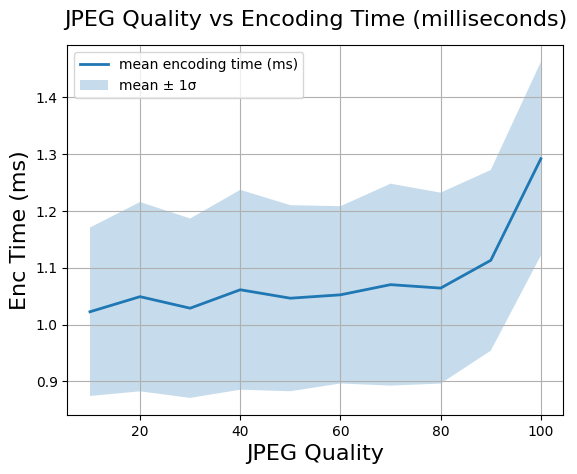

In [9]:
# Aggregate per quality across experiments
stats = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean encoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")
ax.legend()
plt.show()

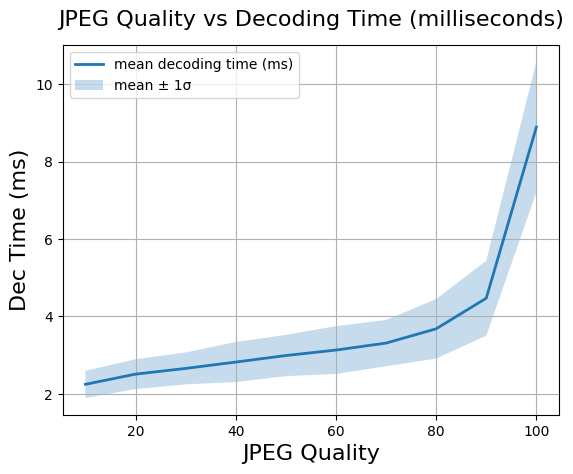

In [10]:
# Aggregate per quality across experiments
stats = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean decoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")
ax.legend()
plt.show()

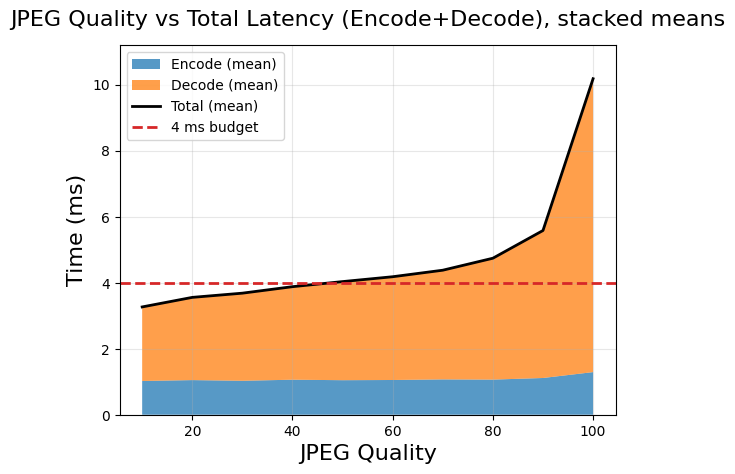

In [11]:
# Aggregate both metrics per quality (means + stds, in case you want them later)
stats = (
    df[df["subsampling"] == 420].groupby("quality", as_index=False)
      .agg(enc_mean=("enc_avg_time_milliseconds", "mean"),
           enc_std =("enc_avg_time_milliseconds", "std"),
           dec_mean=("dec_avg_time_milliseconds", "mean"),
           dec_std =("dec_avg_time_milliseconds", "std"))
      .sort_values("quality")
)

q   = stats["quality"].to_numpy()
enc = stats["enc_mean"].to_numpy()
dec = stats["dec_mean"].to_numpy()

total = enc + dec

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Total Latency (Encode+Decode), stacked means", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Time (ms)", fontsize=16)
ax.grid(True, alpha=0.3)

# Stacked mean areas
ax.stackplot(q, enc, dec, labels=["Encode (mean)", "Decode (mean)"], alpha=0.75)

# Total mean line (optional but usually useful)
ax.plot(q, total, color="black", linewidth=2, label="Total (mean)")

# 4 ms total latency budget
ax.axhline(4.0, color="tab:red", linestyle="--", linewidth=2, label="4 ms budget")

# Make sure budget line is visible
ax.set_ylim(bottom=0, top=max(total.max(), 4.0) * 1.1)

ax.legend(loc="upper left")
plt.show()